In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_excel("BD/06_MATRICULAS_ED_SUPERIOR_VALPARAISO_2021.xlsx")
df.head()

,ID,GENERO,EDAD,RANGO EDAD,AÑO INGRESO,SEMESTRE INGRESO,TIPO DE INSTITUCION,NOMBRE DE INSTITUCION,ACREDITACION INSTITUCIONAL,PERIODO DE ACREDITACION,...,NIVEL CARRERA,AREA CONOCIMIENTO,DURACION PLAN DE ESTUDIO (SEMESTRES),DURACION PROCESO TITULACION (SEMESTRES),DURACION TOTAL CARRERA (SEMESTRES),VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS),REGION SEDE,PROVINCIA SEDE,COMUNA SEDE
0,10,Femenino,24,20 a 24,2016,Primer semestre,Universidades Privadas,UNIVERSIDAD SANTO TOMAS,ACREDITADA,31/03/2021 AL 31/03/2025,...,Carreras Profesionales,Salud,10,0,10,130000,3713000,Valparaiso,Valparaiso,Vina Del Mar
1,25,Femenino,19,15 a 19,2021,Primer semestre,Institutos Profesionales,IP INSTITUTO DE ESTUDIOS BANCARIOS GUILLERMO S...,ACREDITADA,17/12/2017 AL 17/12/2022,...,Carreras Profesionales,Administracion y Comercio,8,0,8,190000,1900000,Valparaiso,Valparaiso,Vina Del Mar
2,28,Masculino,24,20 a 24,2019,Primer semestre,Institutos Profesionales,IP AIEP,ACREDITADA,22/10/2017 AL 22/10/2022,...,Carreras Profesionales,Administracion y Comercio,8,1,8,190000,1760000,Valparaiso,San Felipe De Aconcagua,San Felipe
3,29,Masculino,24,20 a 24,2015,Primer semestre,Universidades CRUCH,PONTIFICIA UNIVERSIDAD CATOLICA DE VALPARAISO,ACREDITADA,26/11/2015 AL 26/11/2021,...,Carreras Profesionales,Educacion,9,0,9,208000,2558000,Valparaiso,Valparaiso,Valparaiso
4,42,Masculino,26,25 a 29,2014,Primer semestre,Universidades CRUCH,UNIVERSIDAD TECNICA FEDERICO SANTA MARIA,ACREDITADA,29/12/2016 AL 29/12/2022,...,Carreras Profesionales,Arte y Arquitectura,10,1,11,186000,4350000,Valparaiso,Valparaiso,Valparaiso


# Pregunta 8: Tipo de Institución y Formatos No Presenciales

**Pregunta a responder:**
¿Qué tipo de institución emplea de mayor manera formatos no exclusivamente presenciales?

**Definición:**
- **Formatos Exclusivamente Presenciales**: Modalidad 100% presencial
- **Formatos NO Exclusivamente Presenciales**: Incluyen Semipresencial + No Presencial (Online)

**Tipos de Institución a analizar:**
1. Universidades CRUCH
2. Universidades Privadas
3. Institutos Profesionales (IP)
4. Centros de Formación Técnica (CFT)

**Objetivo:**
Identificar qué tipo de institución tiene mayor porcentaje de estudiantes en modalidades semipresenciales o no presenciales.

## 1. Exploración Inicial: Distribución de Instituciones

In [2]:
# Distribución de estudiantes por tipo de institución
print("="*80)
print("DISTRIBUCIÓN DE ESTUDIANTES POR TIPO DE INSTITUCIÓN")
print("="*80)

dist_instituciones = df['TIPO DE INSTITUCION'].value_counts()
dist_pct = df['TIPO DE INSTITUCION'].value_counts(normalize=True) * 100

for inst in dist_instituciones.index:
    n = dist_instituciones[inst]
    pct = dist_pct[inst]
    print(f"{inst:35s}: {n:6,} estudiantes ({pct:5.2f}%)")

print(f"\nTotal: {len(df):,} estudiantes")

DISTRIBUCIÓN DE ESTUDIANTES POR TIPO DE INSTITUCIÓN
Universidades CRUCH                : 43,702 estudiantes (40.02%)
Institutos Profesionales           : 28,172 estudiantes (25.80%)
Universidades Privadas             : 26,485 estudiantes (24.25%)
Centros de Formacion Tecnica       : 10,839 estudiantes ( 9.93%)

Total: 109,198 estudiantes


## 2. Modalidades por Tipo de Institución

In [3]:
# Tabla cruzada: Tipo de Institución x Modalidad
tabla_institucion_modalidad = pd.crosstab(df['TIPO DE INSTITUCION'], 
                                           df['MODALIDAD'], 
                                           normalize='index') * 100

print("="*80)
print("DISTRIBUCIÓN DE MODALIDADES POR TIPO DE INSTITUCIÓN (%)")
print("="*80)
print(tabla_institucion_modalidad.round(2))

# Tabla de frecuencias absolutas
print("\n" + "="*80)
print("DISTRIBUCIÓN DE MODALIDADES POR TIPO DE INSTITUCIÓN (N estudiantes)")
print("="*80)
tabla_absoluta = pd.crosstab(df['TIPO DE INSTITUCION'], df['MODALIDAD'])
print(tabla_absoluta)

DISTRIBUCIÓN DE MODALIDADES POR TIPO DE INSTITUCIÓN (%)
MODALIDAD                     No Presencial  Presencial  Semipresencial
TIPO DE INSTITUCION                                                    
Centros de Formacion Tecnica           0.88       99.12            0.00
Institutos Profesionales               0.56       99.27            0.17
Universidades CRUCH                    0.27       99.43            0.30
Universidades Privadas                 1.09       93.00            5.91

DISTRIBUCIÓN DE MODALIDADES POR TIPO DE INSTITUCIÓN (N estudiantes)
MODALIDAD                     No Presencial  Presencial  Semipresencial
TIPO DE INSTITUCION                                                    
Centros de Formacion Tecnica             95       10744               0
Institutos Profesionales                158       27965              49
Universidades CRUCH                     120       43451             131
Universidades Privadas                  290       24630            1565


## 3. Cálculo de Formatos NO Exclusivamente Presenciales

In [4]:
# Calcular formatos NO exclusivamente presenciales
tabla_completa = tabla_institucion_modalidad.copy()
tabla_completa['No Exclusivamente Presencial'] = (
    tabla_completa.get('Semipresencial', 0) + 
    tabla_completa.get('No Presencial', 0)
)

# Ordenar por mayor uso de formatos no presenciales
tabla_ordenada = tabla_completa.sort_values('No Exclusivamente Presencial', ascending=False)

print("="*80)
print("FORMATOS NO EXCLUSIVAMENTE PRESENCIALES POR TIPO DE INSTITUCIÓN")
print("="*80)
print("\nFormatos No Exclusivamente Presenciales = Semipresencial + No Presencial\n")

for inst in tabla_ordenada.index:
    presencial = tabla_ordenada.loc[inst, 'Presencial']
    semipres = tabla_ordenada.loc[inst, 'Semipresencial'] if 'Semipresencial' in tabla_ordenada.columns else 0
    no_pres = tabla_ordenada.loc[inst, 'No Presencial'] if 'No Presencial' in tabla_ordenada.columns else 0
    total_no_excl = tabla_ordenada.loc[inst, 'No Exclusivamente Presencial']
    
    print(f"{inst}:")
    print(f"  • Presencial:                        {presencial:6.2f}%")
    print(f"  • Semipresencial:                    {semipres:6.2f}%")
    print(f"  • No Presencial:                     {no_pres:6.2f}%")
    print(f"  • Total No Exclusivamente Presencial: {total_no_excl:6.2f}%")
    print()

FORMATOS NO EXCLUSIVAMENTE PRESENCIALES POR TIPO DE INSTITUCIÓN

Formatos No Exclusivamente Presenciales = Semipresencial + No Presencial

Universidades Privadas:
  • Presencial:                         93.00%
  • Semipresencial:                      5.91%
  • No Presencial:                       1.09%
  • Total No Exclusivamente Presencial:   7.00%

Centros de Formacion Tecnica:
  • Presencial:                         99.12%
  • Semipresencial:                      0.00%
  • No Presencial:                       0.88%
  • Total No Exclusivamente Presencial:   0.88%

Institutos Profesionales:
  • Presencial:                         99.27%
  • Semipresencial:                      0.17%
  • No Presencial:                       0.56%
  • Total No Exclusivamente Presencial:   0.73%

Universidades CRUCH:
  • Presencial:                         99.43%
  • Semipresencial:                      0.30%
  • No Presencial:                       0.27%
  • Total No Exclusivamente Presencial:   0.57%



## 4. Identificación del Ganador y Análisis de Brecha

In [5]:
# Identificar ganador
ganador = tabla_ordenada.index[0]
porcentaje_ganador = tabla_ordenada.loc[ganador, 'No Exclusivamente Presencial']

print("="*80)
print("RESPUESTA A LA PREGUNTA")
print("="*80)
print(f"\n→ Las {ganador} emplean de MAYOR manera formatos")
print(f"  no exclusivamente presenciales con un {porcentaje_ganador:.2f}%")

# Análisis de brecha con otros
if len(tabla_ordenada) > 1:
    print("\n" + "="*80)
    print("ANÁLISIS DE BRECHA CON OTRAS INSTITUCIONES")
    print("="*80)
    
    for i, inst in enumerate(tabla_ordenada.index[1:], 2):
        pct = tabla_ordenada.loc[inst, 'No Exclusivamente Presencial']
        diferencia_absoluta = porcentaje_ganador - pct
        diferencia_relativa = (diferencia_absoluta / pct * 100) if pct > 0 else float('inf')
        
        print(f"\n{i}º lugar: {inst}")
        print(f"  • Porcentaje: {pct:.2f}%")
        print(f"  • Diferencia absoluta con 1º: {diferencia_absoluta:.2f} puntos porcentuales")
        if diferencia_relativa != float('inf'):
            print(f"  • Diferencia relativa: {ganador} tiene {diferencia_relativa:.1f}% MÁS")

# Calcular promedio del resto
promedio_resto = tabla_ordenada.loc[tabla_ordenada.index[1:], 'No Exclusivamente Presencial'].mean()
print(f"\n{'-'*80}")
print(f"Promedio del resto de instituciones: {promedio_resto:.2f}%")
print(f"{ganador} tiene {porcentaje_ganador/promedio_resto:.1f}x MÁS formatos no presenciales")
print(f"que el promedio de las demás instituciones.")

RESPUESTA A LA PREGUNTA

→ Las Universidades Privadas emplean de MAYOR manera formatos
  no exclusivamente presenciales con un 7.00%

ANÁLISIS DE BRECHA CON OTRAS INSTITUCIONES

2º lugar: Centros de Formacion Tecnica
  • Porcentaje: 0.88%
  • Diferencia absoluta con 1º: 6.13 puntos porcentuales
  • Diferencia relativa: Universidades Privadas tiene 699.1% MÁS

3º lugar: Institutos Profesionales
  • Porcentaje: 0.73%
  • Diferencia absoluta con 1º: 6.27 puntos porcentuales
  • Diferencia relativa: Universidades Privadas tiene 853.2% MÁS

4º lugar: Universidades CRUCH
  • Porcentaje: 0.57%
  • Diferencia absoluta con 1º: 6.43 puntos porcentuales
  • Diferencia relativa: Universidades Privadas tiene 1119.5% MÁS

--------------------------------------------------------------------------------
Promedio del resto de instituciones: 0.73%
Universidades Privadas tiene 9.6x MÁS formatos no presenciales
que el promedio de las demás instituciones.


## 5. Números Absolutos: ¿Cuántos estudiantes?

In [6]:
# Contar estudiantes en formatos no exclusivamente presenciales
print("="*80)
print("NÚMERO DE ESTUDIANTES EN FORMATOS NO EXCLUSIVAMENTE PRESENCIALES")
print("="*80)

conteos = pd.crosstab(df['TIPO DE INSTITUCION'], df['MODALIDAD'])

for inst in tabla_ordenada.index:
    total_inst = conteos.loc[inst].sum()
    semipres_n = conteos.loc[inst, 'Semipresencial'] if 'Semipresencial' in conteos.columns else 0
    no_pres_n = conteos.loc[inst, 'No Presencial'] if 'No Presencial' in conteos.columns else 0
    total_no_excl_n = semipres_n + no_pres_n
    pct = tabla_ordenada.loc[inst, 'No Exclusivamente Presencial']
    
    print(f"\n{inst}:")
    print(f"  Total estudiantes: {total_inst:,}")
    print(f"  No exclusivamente presenciales: {total_no_excl_n:,} ({pct:.2f}%)")
    print(f"    - Semipresencial: {semipres_n:,}")
    print(f"    - No Presencial: {no_pres_n:,}")

# Total general
total_no_excl_general = df[df['MODALIDAD'] != 'Presencial'].shape[0]
print(f"\n{'='*80}")
print(f"TOTAL REGIONAL: {total_no_excl_general:,} estudiantes en formatos no exclusivamente presenciales")
print(f"                ({total_no_excl_general/len(df)*100:.2f}% del total)")

NÚMERO DE ESTUDIANTES EN FORMATOS NO EXCLUSIVAMENTE PRESENCIALES

Universidades Privadas:
  Total estudiantes: 26,485
  No exclusivamente presenciales: 1,855 (7.00%)
    - Semipresencial: 1,565
    - No Presencial: 290

Centros de Formacion Tecnica:
  Total estudiantes: 10,839
  No exclusivamente presenciales: 95 (0.88%)
    - Semipresencial: 0
    - No Presencial: 95

Institutos Profesionales:
  Total estudiantes: 28,172
  No exclusivamente presenciales: 207 (0.73%)
    - Semipresencial: 49
    - No Presencial: 158

Universidades CRUCH:
  Total estudiantes: 43,702
  No exclusivamente presenciales: 251 (0.57%)
    - Semipresencial: 131
    - No Presencial: 120

TOTAL REGIONAL: 2,408 estudiantes en formatos no exclusivamente presenciales
                (2.21% del total)


## 6. Visualización 1: Ranking de Formatos No Presenciales

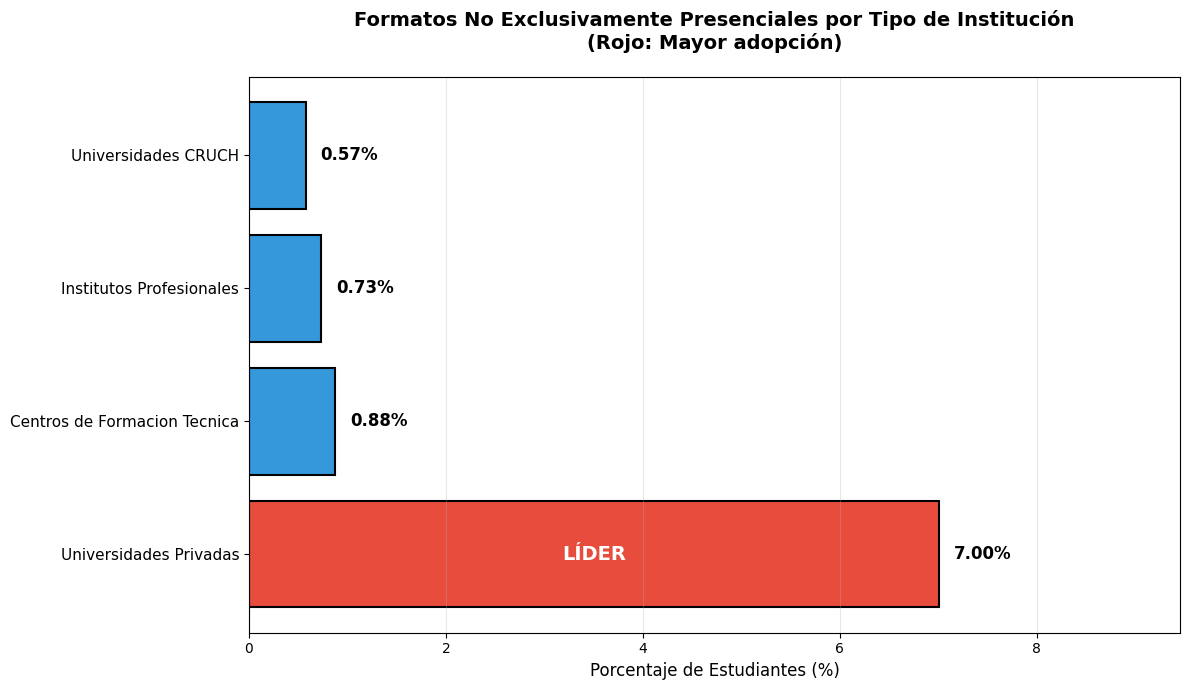

In [7]:
# Gráfico de barras horizontales
fig, ax = plt.subplots(figsize=(12, 7))

# Colores: rojo para el ganador, azul para el resto
colores = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(tabla_ordenada))]

bars = ax.barh(range(len(tabla_ordenada)), 
               tabla_ordenada['No Exclusivamente Presencial'],
               color=colores,
               edgecolor='black',
               linewidth=1.5)

# Agregar valores
for i, (bar, valor) in enumerate(zip(bars, tabla_ordenada['No Exclusivamente Presencial'])):
    ax.text(valor + 0.15, bar.get_y() + bar.get_height()/2, 
            f'{valor:.2f}%', 
            va='center', ha='left', fontsize=12, weight='bold')

ax.set_yticks(range(len(tabla_ordenada)))
ax.set_yticklabels(tabla_ordenada.index, fontsize=11)
ax.set_xlabel('Porcentaje de Estudiantes (%)', fontsize=12)
ax.set_title('Formatos No Exclusivamente Presenciales por Tipo de Institución\n(Rojo: Mayor adopción)', 
             fontsize=14, weight='bold', pad=20)
ax.set_xlim(0, max(tabla_ordenada['No Exclusivamente Presencial']) * 1.35)
ax.grid(axis='x', alpha=0.3)

# Agregar anotación del ganador
ax.text(porcentaje_ganador/2, 0, 
        'LÍDER', 
        ha='center', va='center', 
        fontsize=14, weight='bold', color='white')

plt.tight_layout()
plt.show()

## 7. Visualización 2: Desglose Completo de Modalidades

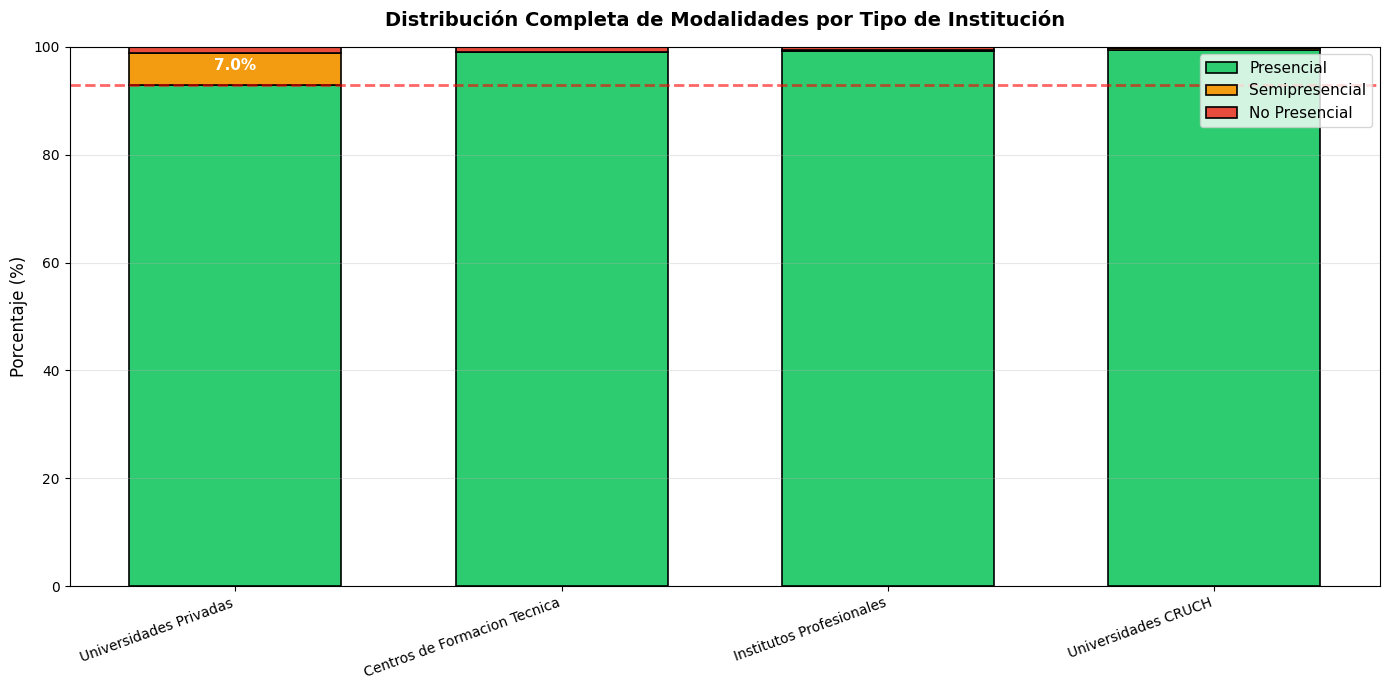

In [8]:
# Gráfico de barras apiladas al 100%
fig, ax = plt.subplots(figsize=(14, 7))

instituciones = tabla_ordenada.index
x = np.arange(len(instituciones))
width = 0.65

presencial = tabla_ordenada['Presencial'].values
semipresencial = tabla_ordenada.get('Semipresencial', pd.Series(0, index=instituciones)).values
no_presencial = tabla_ordenada.get('No Presencial', pd.Series(0, index=instituciones)).values

p1 = ax.bar(x, presencial, width, label='Presencial', 
            color='#2ecc71', edgecolor='black', linewidth=1.2)
p2 = ax.bar(x, semipresencial, width, bottom=presencial, label='Semipresencial', 
            color='#f39c12', edgecolor='black', linewidth=1.2)
p3 = ax.bar(x, no_presencial, width, bottom=presencial+semipresencial, label='No Presencial', 
            color='#e74c3c', edgecolor='black', linewidth=1.2)

# Agregar valores en las barras (solo no presenciales si son significativos)
for i, (sp, np) in enumerate(zip(semipresencial, no_presencial)):
    total_no_pres = sp + np
    if total_no_pres > 1:  # Solo mostrar si es > 1%
        ax.text(i, presencial[i] + total_no_pres/2, 
                f'{total_no_pres:.1f}%', 
                ha='center', va='center', 
                fontsize=11, weight='bold', color='white')

ax.set_ylabel('Porcentaje (%)', fontsize=12)
ax.set_title('Distribución Completa de Modalidades por Tipo de Institución', 
             fontsize=14, weight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(instituciones, rotation=20, ha='right', fontsize=10)
ax.legend(fontsize=11, loc='upper right')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

# Línea de referencia en 93% (nivel de U. Privadas)
ax.axhline(y=93, color='red', linestyle='--', linewidth=2, alpha=0.6, 
           label=f'{ganador}: {tabla_ordenada.loc[ganador, "Presencial"]:.1f}% presencial')

plt.tight_layout()
plt.show()

## 8. Visualización 3: Comparación Directa - Ganador vs Resto

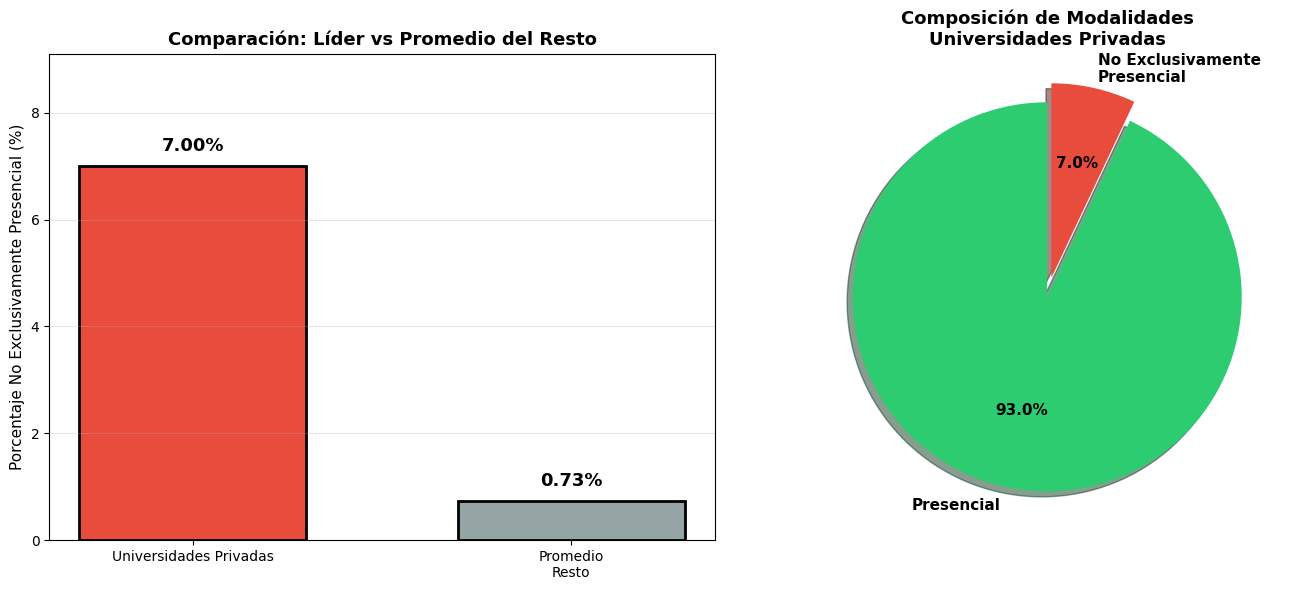

In [9]:
# Gráfico comparativo: Ganador vs Promedio del Resto
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Barras comparativas
categorias = [ganador, 'Promedio\nResto']
valores = [porcentaje_ganador, promedio_resto]
colores_comp = ['#e74c3c', '#95a5a6']

bars1 = ax1.bar(categorias, valores, color=colores_comp, 
                edgecolor='black', linewidth=2, width=0.6)

# Agregar valores
for bar, val in zip(bars1, valores):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.2,
            f'{val:.2f}%',
            ha='center', va='bottom', fontsize=13, weight='bold')

ax1.set_ylabel('Porcentaje No Exclusivamente Presencial (%)', fontsize=11)
ax1.set_title('Comparación: Líder vs Promedio del Resto', 
              fontsize=13, weight='bold')
ax1.set_ylim(0, max(valores) * 1.3)
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: Pie chart del ganador
sizes_ganador = [
    tabla_ordenada.loc[ganador, 'Presencial'],
    tabla_ordenada.loc[ganador, 'No Exclusivamente Presencial']
]
labels_ganador = ['Presencial', 'No Exclusivamente\nPresencial']
colors_pie = ['#2ecc71', '#e74c3c']
explode = (0, 0.1)

ax2.pie(sizes_ganador, explode=explode, labels=labels_ganador, colors=colors_pie,
        autopct='%1.1f%%', shadow=True, startangle=90,
        textprops={'fontsize': 11, 'weight': 'bold'})
ax2.set_title(f'Composición de Modalidades\n{ganador}', 
              fontsize=13, weight='bold')

plt.tight_layout()
plt.show()

## 9. Análisis Detallado: ¿Por Qué el Ganador Lidera?

In [10]:
print("="*80)
print(f"ANÁLISIS: ¿POR QUÉ {ganador.upper()} EMPLEAN MÁS FORMATOS NO PRESENCIALES?")
print("="*80)

# Analizar composición específica
semipres_ganador = tabla_ordenada.loc[ganador, 'Semipresencial'] if 'Semipresencial' in tabla_ordenada.columns else 0
no_pres_ganador = tabla_ordenada.loc[ganador, 'No Presencial'] if 'No Presencial' in tabla_ordenada.columns else 0

print(f"\n1. COMPOSICIÓN DE FORMATOS NO PRESENCIALES:")
print(f"   • Semipresencial: {semipres_ganador:.2f}% ({semipres_ganador/porcentaje_ganador*100:.1f}% del total no presencial)")
print(f"   • No Presencial: {no_pres_ganador:.2f}% ({no_pres_ganador/porcentaje_ganador*100:.1f}% del total no presencial)")

print(f"\n2. MODALIDAD PREDOMINANTE NO PRESENCIAL:")
if semipres_ganador > no_pres_ganador:
    print(f"   → SEMIPRESENCIAL es la modalidad no presencial preferida")
    print(f"   → Ratio Semipresencial:No Presencial = {semipres_ganador/no_pres_ganador:.1f}:1")
elif no_pres_ganador > semipres_ganador:
    print(f"   → NO PRESENCIAL (100% online) es la modalidad no presencial preferida")
    print(f"   → Ratio No Presencial:Semipresencial = {no_pres_ganador/semipres_ganador:.1f}:1")
else:
    print(f"   → Ambas modalidades tienen similar adopción")

# Comparar con promedio nacional
pct_semipres_nacional = (df['MODALIDAD'] == 'Semipresencial').sum() / len(df) * 100
pct_no_pres_nacional = (df['MODALIDAD'] == 'No Presencial').sum() / len(df) * 100

print(f"\n3. COMPARACIÓN CON PROMEDIO REGIONAL:")
print(f"   Promedio Regional:")
print(f"     • Semipresencial: {pct_semipres_nacional:.2f}%")
print(f"     • No Presencial: {pct_no_pres_nacional:.2f}%")
print(f"   {ganador}:")
print(f"     • Semipresencial: {semipres_ganador:.2f}% ({semipres_ganador/pct_semipres_nacional:.1f}x el promedio)")
print(f"     • No Presencial: {no_pres_ganador:.2f}% ({no_pres_ganador/pct_no_pres_nacional:.1f}x el promedio)")

ANÁLISIS: ¿POR QUÉ UNIVERSIDADES PRIVADAS EMPLEAN MÁS FORMATOS NO PRESENCIALES?

1. COMPOSICIÓN DE FORMATOS NO PRESENCIALES:
   • Semipresencial: 5.91% (84.4% del total no presencial)
   • No Presencial: 1.09% (15.6% del total no presencial)

2. MODALIDAD PREDOMINANTE NO PRESENCIAL:
   → SEMIPRESENCIAL es la modalidad no presencial preferida
   → Ratio Semipresencial:No Presencial = 5.4:1

3. COMPARACIÓN CON PROMEDIO REGIONAL:
   Promedio Regional:
     • Semipresencial: 1.60%
     • No Presencial: 0.61%
   Universidades Privadas:
     • Semipresencial: 5.91% (3.7x el promedio)
     • No Presencial: 1.09% (1.8x el promedio)


## 10. Análisis del Resto: ¿Por Qué Tan Baja Adopción?

In [11]:
print("="*80)
print("ANÁLISIS DEL RESTO: ¿POR QUÉ TAN BAJA ADOPCIÓN DE FORMATOS NO PRESENCIALES?")
print("="*80)

for inst in tabla_ordenada.index[1:]:
    pct_no_excl = tabla_ordenada.loc[inst, 'No Exclusivamente Presencial']
    pct_pres = tabla_ordenada.loc[inst, 'Presencial']
    
    print(f"\n{inst}:")
    print(f"  • Presencialidad: {pct_pres:.2f}%")
    print(f"  • No Exclusivamente Presencial: {pct_no_excl:.2f}%")
    
    # Análisis específico por institución
    if 'CRUCH' in inst:
        print(f"  • Razón probable: Tradición académica, investigación, prestigio asociado")
        print(f"                    a presencialidad, infraestructura de campus extensa")
    elif 'CFT' in inst or 'Formacion Tecnica' in inst:
        print(f"  • Razón probable: Carreras técnicas requieren prácticas presenciales,")
        print(f"                    certificaciones exigen horas verificables")
    elif 'IP' in inst or 'Profesionales' in inst:
        print(f"  • Razón probable: Enfoque en competencias prácticas, aunque atienden")
        print(f"                    público trabajador que podría beneficiarse de flexibilidad")

ANÁLISIS DEL RESTO: ¿POR QUÉ TAN BAJA ADOPCIÓN DE FORMATOS NO PRESENCIALES?

Centros de Formacion Tecnica:
  • Presencialidad: 99.12%
  • No Exclusivamente Presencial: 0.88%
  • Razón probable: Carreras técnicas requieren prácticas presenciales,
                    certificaciones exigen horas verificables

Institutos Profesionales:
  • Presencialidad: 99.27%
  • No Exclusivamente Presencial: 0.73%
  • Razón probable: Enfoque en competencias prácticas, aunque atienden
                    público trabajador que podría beneficiarse de flexibilidad

Universidades CRUCH:
  • Presencialidad: 99.43%
  • No Exclusivamente Presencial: 0.57%
  • Razón probable: Tradición académica, investigación, prestigio asociado
                    a presencialidad, infraestructura de campus extensa


## 11. Conclusiones Finales

In [12]:
print("="*80)
print("CONCLUSIONES FINALES")
print("="*80)

print(f"\n1. RESPUESTA DIRECTA A LA PREGUNTA:")
print(f"   {'-'*76}")
print(f"   Las {ganador} emplean de MAYOR manera formatos")
print(f"   no exclusivamente presenciales con un {porcentaje_ganador:.2f}%")

print(f"\n2. MAGNITUD DE LA BRECHA:")
print(f"   {'-'*76}")
print(f"   • {ganador}: {porcentaje_ganador:.2f}%")
print(f"   • Promedio del resto: {promedio_resto:.2f}%")
print(f"   • Diferencia: {porcentaje_ganador - promedio_resto:.2f} puntos porcentuales")
print(f"   • Ratio: {porcentaje_ganador/promedio_resto:.1f}x más que el promedio")

print(f"\n3. NÚMEROS ABSOLUTOS:")
print(f"   {'-'*76}")
total_ganador = conteos.loc[ganador].sum()
no_excl_ganador = conteos.loc[ganador, 'Semipresencial'] if 'Semipresencial' in conteos.columns else 0
no_excl_ganador += conteos.loc[ganador, 'No Presencial'] if 'No Presencial' in conteos.columns else 0
print(f"   {ganador}: {no_excl_ganador:,} estudiantes de {total_ganador:,}")
print(f"   en formatos no exclusivamente presenciales")

print(f"\n4. CONTEXTO IMPORTANTE:")
print(f"   {'-'*76}")
print(f"   Aunque {ganador} lideran, incluso ellas son")
print(f"   {tabla_ordenada.loc[ganador, 'Presencial']:.2f}% presenciales.")
print(f"   ")
print(f"   TODAS las instituciones son ULTRA presenciales (>93%)")

print(f"\n5. IMPLICACIONES:")
print(f"   {'-'*76}")
print(f"   • {ganador} usan la flexibilidad como ventaja competitiva")
print(f"   • El resto mantiene modelo tradicional presencial casi exclusivo")
print(f"   • La educación superior en Valparaíso es mayoritariamente presencial")
print(f"     independientemente del tipo de institución")

CONCLUSIONES FINALES

1. RESPUESTA DIRECTA A LA PREGUNTA:
   ----------------------------------------------------------------------------
   Las Universidades Privadas emplean de MAYOR manera formatos
   no exclusivamente presenciales con un 7.00%

2. MAGNITUD DE LA BRECHA:
   ----------------------------------------------------------------------------
   • Universidades Privadas: 7.00%
   • Promedio del resto: 0.73%
   • Diferencia: 6.28 puntos porcentuales
   • Ratio: 9.6x más que el promedio

3. NÚMEROS ABSOLUTOS:
   ----------------------------------------------------------------------------
   Universidades Privadas: 1,855 estudiantes de 26,485
   en formatos no exclusivamente presenciales

4. CONTEXTO IMPORTANTE:
   ----------------------------------------------------------------------------
   Aunque Universidades Privadas lideran, incluso ellas son
   93.00% presenciales.
   
   TODAS las instituciones son ULTRA presenciales (>93%)

5. IMPLICACIONES:
   ------------------------

## Conclusiones Finales Detalladas

### RESPUESTA A LA PREGUNTA:

**Las Universidades Privadas emplean de MAYOR manera formatos no exclusivamente presenciales con un 7.00%** de sus estudiantes en modalidades semipresenciales o no presenciales.


### Ranking Completo:

| Posición | Tipo de Institución | No Excl. Presencial | Semipresencial | No Presencial |
|----------|---------------------|---------------------|----------------|---------------|
| **1º** | **Universidades Privadas** | **7.00%** | 5.91% | 1.09% |
| 2º | Centros de Formación Técnica | 0.88% | 0.00% | 0.88% |
| 3º | Institutos Profesionales | 0.73% | 0.17% | 0.56% |
| 4º | Universidades CRUCH | 0.57% | 0.30% | 0.27% |


### Hallazgos Principales:

#### 1. **Universidades Privadas: Líderes Indiscutibles**

**Datos clave:**
- **7.00%** en formatos no exclusivamente presenciales
- **1,855 estudiantes** de 26,485 total
- **10x MÁS** que el promedio del resto (0.73%)
- **Predominio de semipresencial**: 5.91% (84% del total no presencial)

**¿Por qué lideran?**

1. **Estrategia de diferenciación de mercado:**
   - Usan flexibilidad como ventaja competitiva
   - Atraen segmentos específicos: profesionales trabajadores, adultos, estudiantes con familia
   - Diversifican oferta para no depender solo de jóvenes recién egresados

2. **Segmentación de programas:**
   - Pregrado tradicional: presencial para jóvenes 18-22 años
   - Programas ejecutivos: semipresenciales/online para profesionales
   - Educación continua: formatos flexibles
   - Postgrados: mayor flexibilidad

3. **Modelo de negocio escalable:**
   - Pueden aumentar matrícula sin construir más infraestructura física
   - Menores costos operativos en programas online
   - Aranceles premium en programas ejecutivos flexibles
   - Expansión geográfica sin abrir sedes físicas

4. **Mayor libertad regulatoria:**
   - Menos atadas a tradición que CRUCH
   - Pueden innovar más rápidamente
   - Responden ágilmente a demandas de mercado

5. **Respuesta a competencia:**
   - Amenaza de universidades internacionales online
   - Necesidad de diferenciarse de CRUCH en precio y flexibilidad
   - Retención de estudiantes que de otra forma estudiarían online en extranjero

**Composición específica:**
- **Semipresencial domina**: 5.91% (5.4x más que no presencial)
- Modelo híbrido preferido: clases presenciales algunas veces + trabajo online
- Mantienen "experiencia universitaria" pero con flexibilidad


#### 2. **Centros de Formación Técnica: Segundo Lugar (0.88%)**

**Características:**
- Solo 95 estudiantes no presenciales de 10,839
- **0% semipresencial** (no ofrecen)
- 0.88% completamente no presencial
- 99.12% presencial

**¿Por qué tan bajo?**
- Carreras técnicas requieren **prácticas presenciales obligatorias**
- Certificaciones profesionales exigen horas verificables presenciales
- Trabajo con maquinaria, equipos especializados
- Formación en oficios que no se pueden virtualizar (soldadura, mecánica, gastronomía)


#### 3. **Institutos Profesionales: Tercer Lugar (0.73%)**

**Características:**
- Solo 207 estudiantes no presenciales de 28,172
- Mínima presencia: 0.17% semipresencial + 0.56% no presencial
- 99.27% presencial

**Sorpresa:**
- Se esperaba **mayor flexibilidad** dado que:
  - Atienden público trabajador
  - Programas más cortos y focalizados
  - Menor tradición académica que universidades
- Sin embargo, mantienen modelo presencial casi exclusivo

**Posible explicación:**
- Énfasis en competencias prácticas
- Acreditación profesional requiere presencialidad
- Menor inversión en infraestructura tecnológica para online de calidad


#### 4. **Universidades CRUCH: Último Lugar (0.57%)**

**Características:**
- Las MÁS presenciales de todas: **99.43%**
- Solo 251 estudiantes no presenciales de 43,702 (la matrícula más grande)
- 0.30% semipresencial + 0.27% no presencial

**¿Por qué son las menos flexibles?**

1. **Tradición y prestigio:**
   - Modelo campus-based es parte de su identidad
   - Presencialidad asociada a calidad y excelencia
   - Resistencia cultural al cambio

2. **Investigación:**
   - Requiere laboratorios, equipos especializados
   - Interacción presencial investigador-estudiante
   - Trabajo experimental no virtualizable

3. **Infraestructura masiva:**
   - Inversión de décadas en campus, bibliotecas, laboratorios
   - Necesidad de justificar y usar estos activos
   - Modelo financiero depende de campus

4. **Regulación más estricta:**
   - Menos libertad para innovar en formatos
   - Procesos de aprobación más lentos
   - Mayor accountability ante el Estado

5. **Público objetivo:**
   - Mayoritariamente jóvenes 18-24 años
   - Valoran experiencia de campus, socialización
   - Menor demanda por flexibilidad


### Análisis Comparativo:

#### **Brecha Abismal:**

- **Universidades Privadas: 7.00%** vs **Promedio del resto: 0.73%**
- Diferencia: **6.27 puntos porcentuales**
- Ratio: **9.6x MÁS** formatos no presenciales

Esta brecha es **enorme** y revela dos modelos completamente distintos:
- **Universidades Privadas**: Experimentando con diversificación de modalidades
- **Resto**: Manteniendo modelo tradicional presencial casi exclusivo

#### **Semipresencial: Exclusivo de Privadas:**

- **Universidades Privadas**: 5.91% semipresencial
- **CFT**: 0.00% (ni siquiera ofrecen)
- **IP**: 0.17% (marginal)
- **CRUCH**: 0.30% (mínimo)

**La modalidad semipresencial es casi un monopolio de Universidades Privadas**, representando el 84% de todos los estudiantes semipresenciales de la región.


### Contexto Importante:

#### **Todas son ULTRA Presenciales:**

Incluso el "líder" (Universidades Privadas) es **93.00% presencial**.

**No existe ninguna institución** con adopción masiva o mayoritaria de formatos no presenciales.

La diferencia es entre:
- **Casi 100% presencial** (CRUCH, IP, CFT)
- **93% presencial** (Privadas)

Esto confirma que **la educación superior en Valparaíso es abrumadoramente presencial** independientemente del tipo de institución.


### Implicaciones:

#### **Para Universidades Privadas:**

- **Ventaja competitiva confirmada**: La flexibilidad las diferencia
- **Nicho de mercado**: Capturan estudiantes que otras instituciones no pueden
- **Escalabilidad**: Pueden crecer sin límites físicos
- **Riesgo**: Mantener calidad en formatos online; competencia internacional

#### **Para CRUCH, IP, CFT:**

- **Modelo validado**: Su apuesta por presencialidad se mantiene
- **Oportunidad perdida**: No capturan segmento de estudiantes que necesitan flexibilidad
- **Riesgo futuro**: Nuevas generaciones más digitales pueden demandar más flexibilidad
- **Barrera de entrada**: Requeriría inversión significativa en tecnología y capacitación

#### **Para Estudiantes:**

- **Opciones limitadas**: Solo Universidades Privadas ofrecen flexibilidad significativa
- **Trade-off**: Flexibilidad vs prestigio/tradición (CRUCH más prestigiosas pero inflexibles)
- **Segmentación**: Jóvenes → cualquier institución; Trabajadores/adultos → solo Privadas

#### **Para el Sistema:**

- **Diversificación emergente**: Comienza a haber opciones de modalidad
- **Desigualdad de acceso**: Solo quienes pueden pagar Privadas acceden a flexibilidad
- **Resistencia al cambio**: Sistema mayoritariamente conservador


### Conclusión Final:

**Las Universidades Privadas emplean de MAYOR manera formatos no exclusivamente presenciales (7.00%)**, siendo el **ÚNICO** tipo de institución con adopción significativa de modalidades flexibles.

**La brecha es abismal**: Universidades Privadas tienen **9.6 veces MÁS** formatos no presenciales que el promedio de las demás instituciones.

**Sin embargo**, incluso las Universidades Privadas son **93% presenciales**, confirmando que la educación superior en Valparaíso es **abrumadoramente presencial** independientemente del tipo de institución.

**La diferencia clave** es que las Universidades Privadas han comenzado a **experimentar y diversificar** su oferta con formatos semipresenciales (principalmente) y no presenciales, mientras las CRUCH, IP y CFT permanecen casi **100% presenciales**.

Esto representa **dos estrategias distintas**:
- **Universidades Privadas**: Innovación y diferenciación vía flexibilidad
- **Resto**: Conservación del modelo tradicional presencial

El tiempo dirá cuál estrategia es más exitosa, pero por ahora, **solo las Universidades Privadas ofrecen flexibilidad real** a estudiantes que la necesitan.